In [60]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import os
import seaborn as sb

In [61]:
level1_marker = {
    'Bcell': ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2'],
    # 'Plasma cell': ['IGKC', 'IGHM', 'IGHA1', 'IGLC2', 'IGLC3', 'JCHAIN'],
    'Plasma cell': ['MZB1','PIM','ENAM','IGHA2'],
    'Tcell': ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3'],
    'NK': ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY'],
    'DC': ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1'],
    "cdc1" : ["CLEC9A", "IRF8", "SNX3"],
    "cdc2" : ["CD1C", "CLEC10A", "FCER1A"],
    "mature dc" : ["CD40", "CD200", "TNFRSF4", "CD274", "LAMP3", "MARCKSL1", "IDO1"],
    "pDC" : ['CLEC4C', 'LILRA4', 'IL3RA', 'TCF4', 'TCL1A', 'SPIB', 'GZMB', 'NRP1', 'IRF7', 'IRF8', 'SLC15A4'],
    'EC': ['PECAM1', 'VWF', 'FABP4', 'CLDN5', 'IFI27', 'ECSCR', 'DYSF', 'CD34', 'COL4A1', 'COL4A2', 'SPARCL1', 'PLVAP', 'MPZL2', 'SULF1', 'EDN1'],
    'Fibroblast': ['LUM', 'DCN', 'COL1A1', 'COL1A2', 'FBLN1', 'THY1', "C3", "C7"],
    'Fibromyocyte': ['FN1', 'LUM', 'TNFRSF11B', 'ACTA2', 'TCF21'],
    'Fibromyocyte_miller': ["FN1", "VCAN", "LTBP1", "COL4A2", "COL6A2"],
    'SMC': ['ACTA2', 'MYH11', 'MYL9', 'TPM2', 'CALD1', 'TAGLN', 'TNFRSF11B', 'LUM', 'APOE', 'APOC1', 'AGT', 'NOTCH3', 'PDGFRB', 'MFAP4'],
    'Macrophage': ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD14', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3'],
    'Monocyte': ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS'],
    'Mast': ['TPSAB1', 'TPSB2', 'KIT', 'HDC', 'CMA1'],
    'Neuron': ['PLP1'],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"]  
}

In [62]:
# 包含none
# level1_marker_mouse = {
#     'Bcell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2a'],
#     'Plasma cell': ['Igkc', 'Ighm', 'Igha', 'Iglc2', 'Iglc2', 'Jchain'],
#     'Tcell': ['Cd2', None, 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
#     'NK': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl1', 'Cd160', 'Fcgr4', 'Prf1', None],
#     'DC': ['Mgl2', 'Fcer1a', None, 'H2-Ea', 'H2-Eb2'],
#     'cdc1': ['Clec9a', 'Irf8', 'Snx3'],
#     'cdc2': [None, 'Mgl2', 'Fcer1a'],
#     'mature dc': ['Cd40', 'Cd200', 'Tnfrsf4', 'Cd274', None, 'Marcksl1', 'Ido1'],
#     'pDC': ['Clec4a3', 'Pirb', None, 'Tcf4', 'Tcl1', 'Spib', 'Gzmc', 'Nrp1', 'Irf7', 'Irf8', 'Slc15a4'],
#     'EC': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', None, None, 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
#     'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1', 'C3', 'C7'],
#     'Fibromyocyte': ['Fn1', 'Lum', 'Tnfrsf11b', 'Acta2', 'Tcf21'],
#     'Fibromyocyte_miller': ['Fn1', 'Vcan', 'Ltbp1', 'Col4a2', 'Col6a2'],
#     'SMC': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
#     'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', None, 'Aif1', 'Cd14', None, 'Itgam', 'Csf1r', 'H2-Ea', 'Lgals3'],
#     'Monocyte': ['Fcnb', 'S100a8', 'Gm5849', None, 'Vcan', 'Cd52', 'Lyz1', 'Ctss'],
#     'Mast': ['Tpsab1', 'Tpsab1', 'Kit', 'Hdc', 'Cma1'],
#     'Neuron': ['Plp1'],
#     'Neutrophil': ['Nampt', 'Ifitm7', 'G0s2', None, None, 'Srgn', 'Aqp9', 'Not found', 'Fcgr4', 'Ivns1abp']
# }
# }

In [95]:
level1_marker_mouse = {
    'Bcell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2a'],
    'Plasma cell': ['Igkc', 'Ighm', 'Igha', 'Iglc2', 'Iglc2', 'Jchain'],
    'Tcell': ['Cd2', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
    'NK': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl1', 'Cd160', 'Fcgr4', 'Prf1'],
    'DC': ['Mgl2', 'Fcer1a','H2-Ea', 'H2-Eb2'],
    'cdc1': ['Clec9a', 'Irf8', 'Snx3'],
    'cdc2': [ 'Mgl2', 'Fcer1a'],
    'mature dc': ['Cd40', 'Cd200', 'Tnfrsf4', 'Cd274',  'Marcksl1', 'Ido1'],
    'pDC': ['Clec4a3', 'Pirb', 'Tcf4', 'Tcl1', 'Spib', 'Gzmc', 'Nrp1', 'Irf7', 'Irf8', 'Slc15a4'],
    'EC': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
    'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1', 'C3', 'C7'],
    'Fibromyocyte': ['Fn1', 'Lum', 'Tnfrsf11b', 'Acta2', 'Tcf21'],
    'Fibromyocyte_miller': ['Fn1', 'Vcan', 'Ltbp1', 'Col4a2', 'Col6a2'],
    'SMC': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
    'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Aif1', 'Cd14', 'Itgam', 'Csf1r', 'H2-Ea', 'Lgals3'],
    'Monocyte': ['Fcnb', 'S100a8', 'Gm5849',  'Vcan', 'Cd52', 'Lyz1', 'Ctss'],
    'Mast': ['Tpsab1', 'Tpsab1', 'Kit', 'Hdc', 'Cma1'],
    'Neuron': ['Plp1'],
    'Neutrophil': ['Nampt', 'Ifitm7', 'G0s2',  'Srgn', 'Aqp9', 'Fcgr4', 'Ivns1abp']
}

In [96]:
all_genes = set()
for gene_list in level1_marker_mouse.values():
    all_genes.update(gene_list)
all_genes = sorted(all_genes)

data = []
for cell_type, genes in level1_marker_mouse.items():
    row = [1 if gene in genes else 0 for gene in all_genes]
    data.append(row)

ref_df = pd.DataFrame(data, index=level1_marker_mouse.keys(), columns=all_genes)
print(ref_df)

                     Acta2  Agt  Aif1  Apoc1  Apoe  Aqp9  C1qa  C1qb  C1qc  \
Bcell                    0    0     0      0     0     0     0     0     0   
Plasma cell              0    0     0      0     0     0     0     0     0   
Tcell                    0    0     0      0     0     0     0     0     0   
NK                       0    0     0      0     0     0     0     0     0   
DC                       0    0     0      0     0     0     0     0     0   
cdc1                     0    0     0      0     0     0     0     0     0   
cdc2                     0    0     0      0     0     0     0     0     0   
mature dc                0    0     0      0     0     0     0     0     0   
pDC                      0    0     0      0     0     0     0     0     0   
EC                       0    0     0      0     0     0     0     0     0   
Fibroblast               0    0     0      0     0     0     0     0     0   
Fibromyocyte             1    0     0      0     0     0     0  

In [97]:
os.chdir("/home/lixiangyu/zr/Annotate/")

## GSE1312776

In [98]:
adata = sc.read_h5ad("data/Mouse_public_data/GSE131776/GSE131776_postQC.h5ad")

In [99]:
adata.layers['rounded_corrected_counts'] = adata.X.copy()

In [100]:
#check how many cells have zero counts for all genes
cellwise_sum = adata.X.sum(axis=1)
num_cells_zero_counts = (cellwise_sum == 0).sum()
#remove cells with zero counts for all genes
adata = adata[cellwise_sum != 0].copy()
print(num_cells_zero_counts)

0


In [101]:
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker_mouse:
    marker_genes_in_data[celltype] = list(set(level1_marker_mouse[celltype]).intersection(adata.var_names))
    print(celltype, len(set(level1_marker_mouse[celltype]).intersection(adata.var_names))/len(level1_marker_mouse[celltype]))
    print("not included: ", set(level1_marker_mouse[celltype]).difference(adata.var_names))

Bcell 0.8333333333333334
not included:  {'Igkc'}
Plasma cell 0.16666666666666666
not included:  {'Igha', 'Iglc2', 'Ighm', 'Igkc'}
Tcell 1.0
not included:  set()
NK 0.8571428571428571
not included:  set()
DC 0.75
not included:  {'H2-Ea'}
cdc1 1.0
not included:  set()
cdc2 1.0
not included:  set()
mature dc 1.0
not included:  set()
pDC 0.8
not included:  {'Gzmc', 'Tcl1'}
EC 1.0
not included:  set()
Fibroblast 1.0
not included:  set()
Fibromyocyte 1.0
not included:  set()
Fibromyocyte_miller 1.0
not included:  set()
SMC 1.0
not included:  set()
Macrophage 0.9
not included:  {'H2-Ea'}
Monocyte 0.7142857142857143
not included:  {'Gm5849', 'Fcnb'}
Mast 0.8
not included:  set()
Neuron 1.0
not included:  set()
Neutrophil 1.0
not included:  set()


In [102]:
(adata.obs['sample'])

AAACCTGGTCAGTGGA-1      1
AAACGGGAGATTACCC-1      1
AAACGGGCATGGAATA-1      1
AAACGGGGTAATAGCA-1      1
AAACGGGGTCTAGGTT-1      1
                       ..
TTTGCGCCAACACCCG-18    18
TTTGCGCCAGAAGCAC-18    18
TTTGGTTCACTCGACG-18    18
TTTGTCAAGAAGGTTT-18    18
TTTGTCACAAGCGCTC-18    18
Name: sample, Length: 24032, dtype: category
Categories (18, object): ['1', '2', '3', '4', ..., '15', '16', '17', '18']

In [103]:
#Perform a clustering for scran normalization in clusters
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp, target_sum=1e6)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, svd_solver="arpack")
sc.pp.neighbors(adata_pp, n_pcs=30)
sc.tl.leiden(adata_pp, key_added='groups', resolution=0.22)

In [104]:
import rpy2.rinterface_lib.callbacks
import logging

from rpy2.robjects import pandas2ri
import anndata2ri

# Ignore R warning messages
#Note: this can be commented out to get more verbose R output
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

# Automatically convert rpy2 outputs to pandas dataframes
pandas2ri.activate()
anndata2ri.activate()
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


/tmp/ipykernel_1402941/2253401465.py:13: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [105]:
#Preprocess variables for scran normalization
input_groups = adata_pp.obs['groups']
data_mat = adata.X.T 

In [106]:
%%R -i data_mat -i input_groups -o size_factors
library(scran)
library(Matrix)  # 必须加载此包以支持稀疏矩阵

print("转换稀疏格式")
data_mat <- as(data_mat, "dgCMatrix")  # 从Python的CSC转为R的CSC格式

# 计算size factors（直接操作稀疏矩阵）
size_factors <- calculateSumFactors(data_mat, clusters=input_groups, min.mean=0.1)
print("计算结束")

[1] "转换稀疏格式"
[1] "计算结束"


In [107]:
del adata_pp

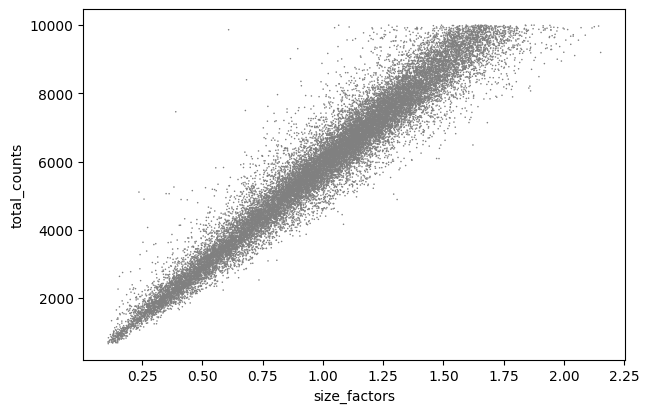

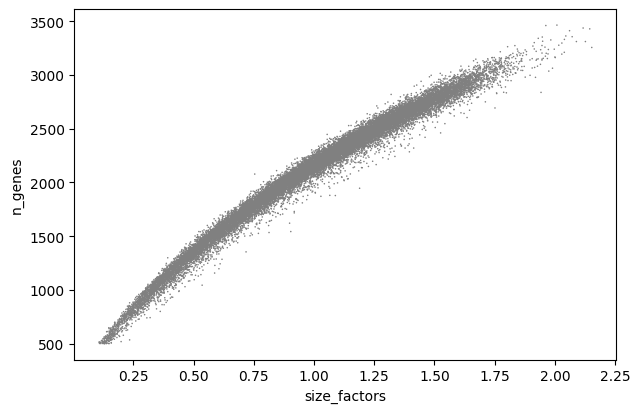

/tmp/ipykernel_1402941/1409471852.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(size_factors, bins=50, kde=False)


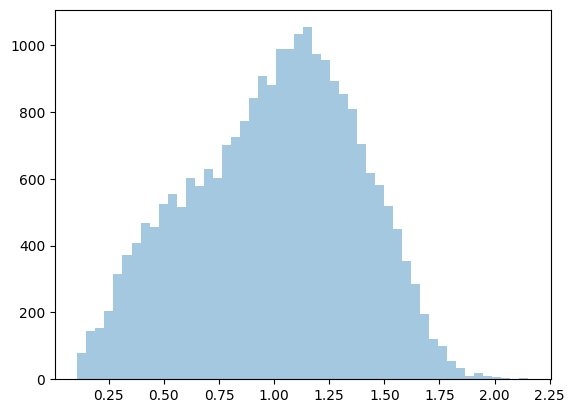

In [108]:
# Visualize the estimated size factors
adata.obs['size_factors'] = size_factors

sc.pl.scatter(adata, 'size_factors', 'total_counts')
sc.pl.scatter(adata, 'size_factors', 'n_genes')

sb.distplot(size_factors, bins=50, kde=False)
plt.show()

In [109]:
adata.X = adata.X.astype(float)
#Normalize adata 
adata.X /= adata.obs['size_factors'].values[:,None]
sc.pp.log1p(adata)

In [110]:
# high variable genes selection
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


In [111]:
adata

AnnData object with n_obs × n_vars = 24032 × 17777
    obs: 'sample', 'dataset', 'symptoms', 'gender', 'age', 'intervention', 'location', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'rounded_corrected_counts'

In [112]:
adata.write("data/Mouse_public_data/GSE131776/GSE131776_pre_annot.h5ad")

In [127]:
adata = sc.read_h5ad("data/Mouse_public_data/GSE131776/GSE131776_pre_annot.h5ad")

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


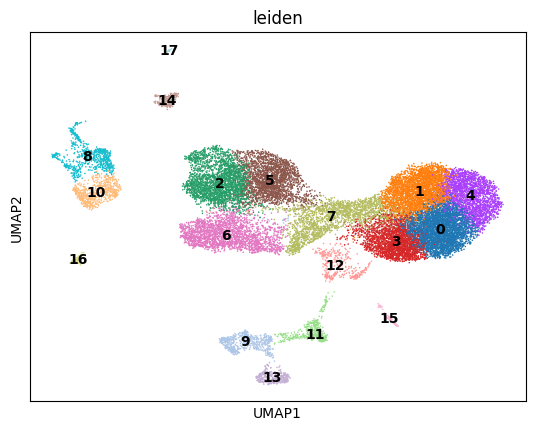

In [128]:
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution = 1)
sc.pl.umap(adata, color= ['leiden'], ncols=1, legend_loc='on data')

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

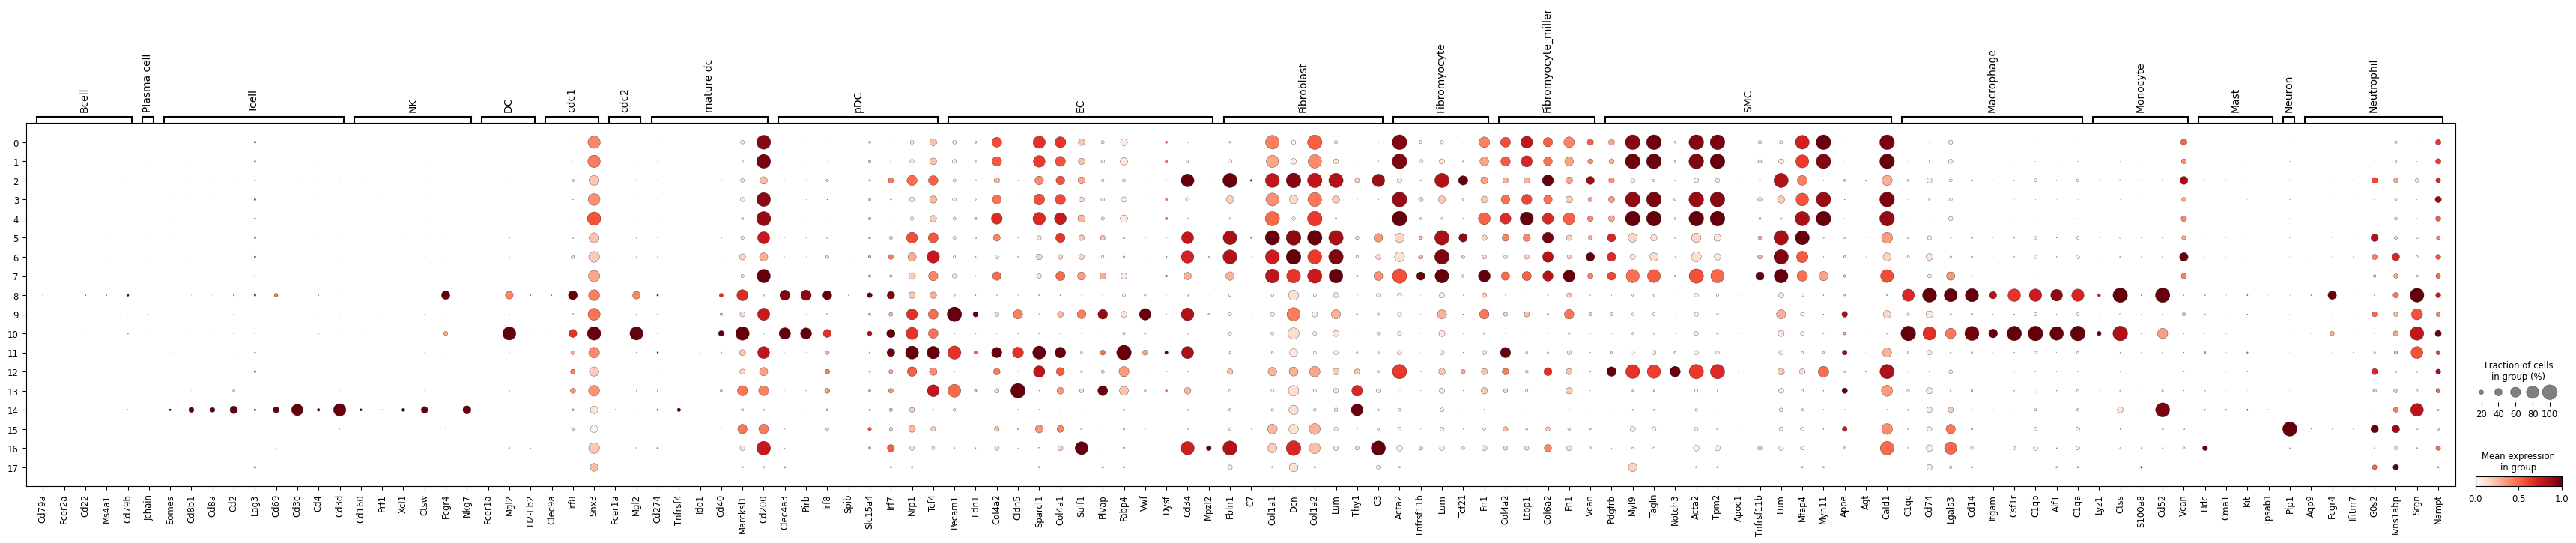

In [130]:
sc.pl.dotplot(
    adata,
    groupby="leiden",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    # save="1_JD.png",
)

In [131]:
##genes_mean
all_marker_genes = []
for gene_list in marker_genes_in_data.values():
    all_marker_genes.extend(gene_list)
all_marker_genes = [gene for gene in all_marker_genes if gene in adata.var_names]

all_marker_genes = list(set(all_marker_genes))
print(len(all_marker_genes))

103


In [132]:
leiden_clusters = adata.obs["leiden"].cat.categories
mean_expression = np.zeros((len(leiden_clusters), len(all_marker_genes)))

for i, cluster in enumerate(leiden_clusters):
    cluster_cells = adata.obs["leiden"] == cluster
    cluster_adata = adata[cluster_cells, :]
    for j, gene in enumerate(all_marker_genes):
        mean_expression[i, j] = np.mean(cluster_adata[:, gene].X)

In [133]:
df = pd.DataFrame(mean_expression, index=leiden_clusters, columns=all_marker_genes)
# csv_file_path = '/home/lixiangyu/zr/Annotate/output_data/1-JD/output/gene_expression_mean.csv'
# df.to_csv(csv_file_path)
# print(df)

In [134]:
# 确保 df 和 ref_df 有共同的基因
common_genes = df.columns.intersection(ref_df.columns)
df = df[common_genes]
ref_df = ref_df[common_genes]

In [135]:
##DISCO-CELLiD------coarse
from scipy.stats import spearmanr
first_round_results = {}
for cluster in df.index:
    cluster_expression = df.loc[cluster]
    correlations = []
    for ref_cell_type in ref_df.index:
        ref_expression = ref_df.loc[ref_cell_type]
        corr, _ = spearmanr(cluster_expression, ref_expression)
        correlations.append((ref_cell_type, corr))
    
    correlations.sort(key=lambda x: x[1], reverse=True)
    retained_types = [ct for ct, corr in correlations if corr > 0.6 or ct in [x[0] for x in correlations[:5]]]
    first_round_results[cluster] = retained_types

In [136]:
##DISCO-CELLiD------fine

second_round_results = {}
for cluster, retained_types in first_round_results.items():
    if len(retained_types) > 0:
        retained_ref_df = ref_df.loc[retained_types]
        variances = retained_ref_df.var()
        top_genes = variances.nlargest(3000).index
        cluster_expression = df.loc[cluster][top_genes]
        retained_ref_df = retained_ref_df[top_genes]
        #spearmanr
        correlations = []
        for ref_cell_type in retained_types:
            ref_expression = retained_ref_df.loc[ref_cell_type]
            corr, _ = spearmanr(cluster_expression, ref_expression)
            correlations.append((ref_cell_type, corr))
        #the highest correlation
        best_cell_type = max(correlations, key=lambda x: x[1])[0]
        second_round_results[cluster] = best_cell_type
    else:
        second_round_results[cluster] = None
# result
print("细胞类型预测结果：")
for cluster, cell_type in second_round_results.items():
    print(f"细胞簇 {cluster} 的预测细胞类型：{cell_type}")

细胞类型预测结果：
细胞簇 0 的预测细胞类型：SMC
细胞簇 1 的预测细胞类型：SMC
细胞簇 2 的预测细胞类型：Fibroblast
细胞簇 3 的预测细胞类型：SMC
细胞簇 4 的预测细胞类型：SMC
细胞簇 5 的预测细胞类型：Fibroblast
细胞簇 6 的预测细胞类型：Fibroblast
细胞簇 7 的预测细胞类型：SMC
细胞簇 8 的预测细胞类型：Macrophage
细胞簇 9 的预测细胞类型：EC
细胞簇 10 的预测细胞类型：Macrophage
细胞簇 11 的预测细胞类型：EC
细胞簇 12 的预测细胞类型：SMC
细胞簇 13 的预测细胞类型：EC
细胞簇 14 的预测细胞类型：Tcell
细胞簇 15 的预测细胞类型：Fibroblast
细胞簇 16 的预测细胞类型：Fibroblast
细胞簇 17 的预测细胞类型：Fibroblast


In [141]:

cluster_annotation1 = {
    "0": "SMC",
    "1": "SMC",
    "2": "Fibroblast",
    "3": "SMC",
    "4": "SMC",
    "5": "Fibroblast",#or Fibroblast
    "6": "Fibroblast", 
    "7": "Fibroblast",
    "8": "Macrophage",
    "9": "EC",
    "10": "Macrophage",
    "11": "EC",#or Fibroblast
    "12": "SMC", 
    "13": "EC",
    "14": "T cell",
    "15": "Fibroblast", 
    "16": "Fibroblast",
    "17": "Fibroblast"
}

In [142]:
adata.obs["cell_type_level1"] = adata.obs.leiden.map(cluster_annotation1)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


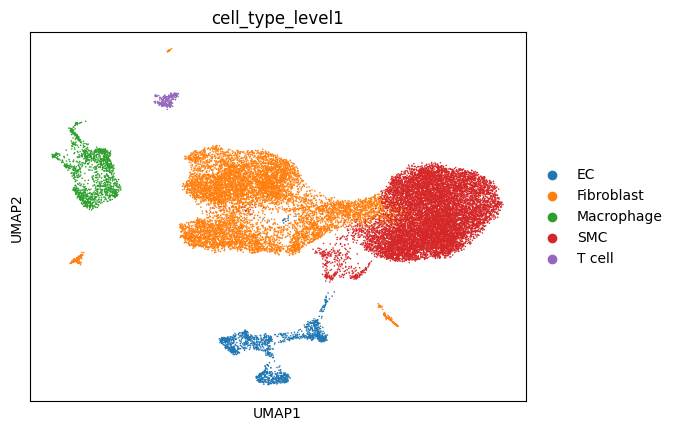

In [143]:
sc.pl.umap(adata, color= ['cell_type_level1'], ncols=1)

In [144]:
adata.write_h5ad("data/Mouse_public_data/GSE131776/GSE131776_annot.h5ad")

In [146]:
adata.obs['cell_type_level1'].value_counts()

cell_type_level1
SMC           11799
Fibroblast     9205
EC             1444
Macrophage     1355
T cell          229
Name: count, dtype: int64